# Outliers

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Let's create a sample of 100 random human ages to exemplify outliers
def create_ages(mu=50,sigma=13,num_samples=100,seed=42):
    np.random.seed(seed)
    sample_ages = np.random.normal(loc=mu,scale=sigma,size=num_samples)
    sample_ages = np.round(sample_ages,decimals=0)
    return sample_ages

sample = create_ages()

In [30]:
sample

array([56., 48., 58., 70., 47., 47., 71., 60., 44., 57., 44., 44., 53.,
       25., 28., 43., 37., 54., 38., 32., 69., 47., 51., 31., 43., 51.,
       35., 55., 42., 46., 42., 74., 50., 36., 61., 34., 53., 25., 33.,
       53., 60., 52., 48., 46., 31., 41., 44., 64., 54., 27., 54., 45.,
       41., 58., 63., 62., 39., 46., 54., 63., 44., 48., 36., 34., 61.,
       68., 49., 63., 55., 42., 55., 70., 50., 70., 16., 61., 51., 46.,
       51., 24., 47., 55., 69., 43., 39., 43., 62., 54., 43., 57., 51.,
       63., 41., 46., 45., 31., 54., 53., 50., 47.])

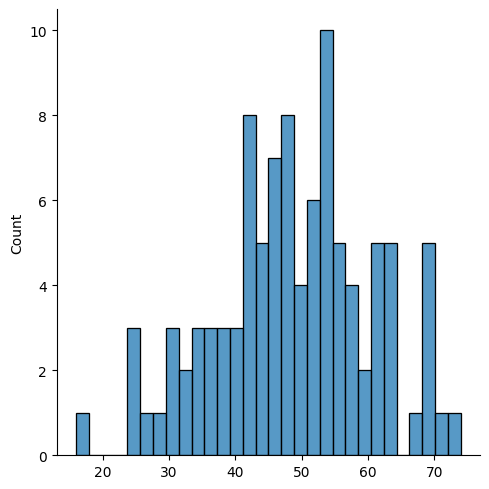

In [31]:
#Visualize the distribution of the sample
sns.displot(sample,bins=30)

This distribution seems to have one outlier below 20, but on the other end, you cannot dismiss all over 65, because they are a relevant portion.

You can also display the dataset with a box plot that will automaticaly identify outliers (with the InterQuartile Range)

<Axes: >

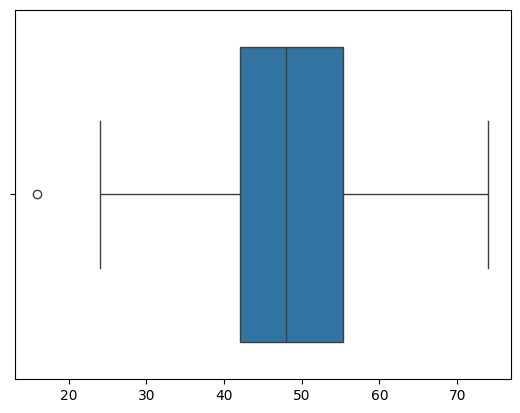

In [32]:
sns.boxplot(sample,orient="h")

so we have one outlier by this method.

Let's identify it (it is the age below 20), in order to remove it from the data set.

In [33]:
q75,q25 = np.percentile(sample,[75,25])
iqr = q75-q25
iqr

np.float64(13.25)

In [34]:
sample[sample>(q25-1.5*iqr)].shape

(99,)

In [35]:
sample = sample[sample>(q25-1.5*iqr)]

<Axes: >

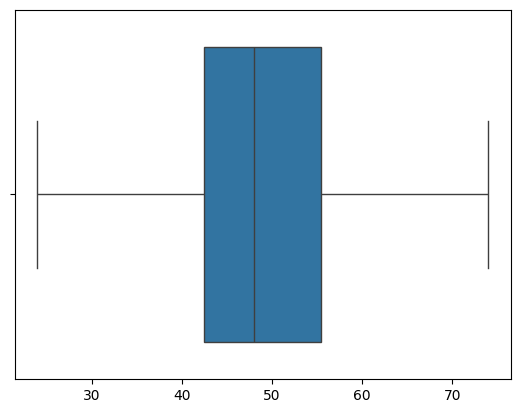

In [36]:
# repeating the boxplot:
sns.boxplot(sample,orient="h")

Let's load the data from our dataset.

In [37]:
df = pd.read_csv('../../jupyter_notebooks/DATA/Ames_Housing_Data.csv')
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


The label we are trying to predict is the SalePrice. So we are interested in having clean and neat the features that will influence most in the prediction, those will be the features highly correlated with the label.

In a data set with so many features, you cannot aim at cleanliness in all features, or you are going to discard a lot of observations.

Let's see the correlation of the features. (_Keep in mind that only numerical features can be used to be correlated: use_ '`select_dtypes()`')

In [38]:
df.select_dtypes(include=['number']).corr()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
PID,1.000000,-0.001281,-0.096918,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,-0.098375,...,-0.051135,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521
MS SubClass,-0.001281,1.000000,-0.420135,-0.204613,0.039419,-0.067349,0.036579,0.043397,0.002730,-0.060075,...,-0.017310,-0.014823,-0.022866,-0.037956,-0.050614,-0.003434,-0.029254,0.000350,-0.017905,-0.085092
Lot Frontage,-0.096918,-0.420135,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,0.215583,...,0.120084,0.163040,0.012758,0.028564,0.076666,0.173947,0.044476,0.011085,-0.007547,0.357318
Lot Area,0.034868,-0.204613,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,0.191555,...,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549
Overall Qual,-0.263147,0.039419,0.212042,0.097188,1.000000,-0.094812,0.597027,0.569609,0.429418,0.284118,...,0.255663,0.298412,-0.140332,0.018240,0.041615,0.030399,0.005179,0.031103,-0.020719,0.799262
Overall Cond,0.104451,-0.067349,-0.074448,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.135340,-0.050935,...,0.020344,-0.068934,0.071459,0.043852,0.044055,-0.016787,0.034056,-0.007295,0.031207,-0.101697
Year Built,-0.343388,0.036579,0.121562,0.023258,0.597027,-0.368773,1.000000,0.612095,0.313292,0.279870,...,0.228964,0.198365,-0.374364,0.015803,-0.041436,0.002213,-0.011011,0.014577,-0.013197,0.558426
Year Remod/Add,-0.157111,0.043397,0.091712,0.021682,0.569609,0.047680,0.612095,1.000000,0.196928,0.151790,...,0.217857,0.241748,-0.220383,0.037412,-0.046888,-0.011410,-0.003132,0.018048,0.032652,0.532974
Mas Vnr Area,-0.229283,0.002730,0.222407,0.126830,0.429418,-0.135340,0.313292,0.196928,1.000000,0.301872,...,0.165467,0.143748,-0.110787,0.013778,0.065643,0.004617,0.044934,-0.000276,-0.017715,0.508285
BsmtFin SF 1,-0.098375,-0.060075,0.215583,0.191555,0.284118,-0.050935,0.279870,0.151790,0.301872,1.000000,...,0.224010,0.124947,-0.100455,0.050541,0.095874,0.084140,0.092886,-0.001155,0.022397,0.432914


This shows all features' correlation with each other.

But knowing we are trying to predict 'SalePrice', we may look at the correlation of that one with all the others only.

In [39]:
df.select_dtypes(include=['number']).corr()['SalePrice'].sort_values()

PID               -0.246521
Enclosed Porch    -0.128787
Kitchen AbvGr     -0.119814
Overall Cond      -0.101697
MS SubClass       -0.085092
Low Qual Fin SF   -0.037660
Bsmt Half Bath    -0.035835
Yr Sold           -0.030569
Misc Val          -0.015691
BsmtFin SF 2       0.005891
3Ssn Porch         0.032225
Mo Sold            0.035259
Pool Area          0.068403
Screen Porch       0.112151
Bedroom AbvGr      0.143913
Bsmt Unf SF        0.182855
Lot Area           0.266549
2nd Flr SF         0.269373
Bsmt Full Bath     0.276050
Half Bath          0.285056
Open Porch SF      0.312951
Wood Deck SF       0.327143
Lot Frontage       0.357318
BsmtFin SF 1       0.432914
Fireplaces         0.474558
TotRms AbvGrd      0.495474
Mas Vnr Area       0.508285
Garage Yr Blt      0.526965
Year Remod/Add     0.532974
Full Bath          0.545604
Year Built         0.558426
1st Flr SF         0.621676
Total Bsmt SF      0.632280
Garage Area        0.640401
Garage Cars        0.647877
Gr Liv Area        0

Now you select the features with higher correlation with 'SalePrice'. Then you can plot each of those features against 'SalePrice'.

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

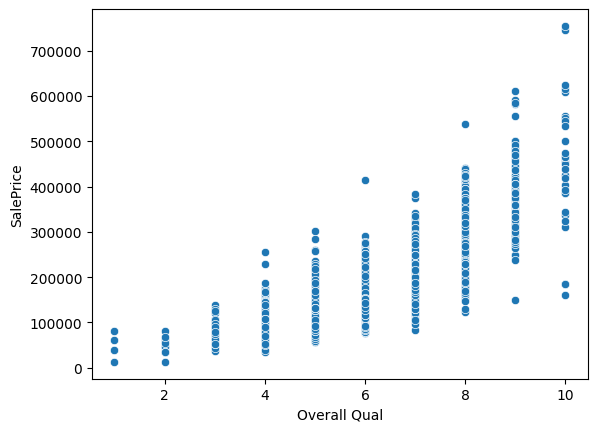

In [40]:
sns.scatterplot(x='Overall Qual', y='SalePrice', data = df)

This shows:
 - first, the 'Overall Qual' is discrete, having only integer values 1 - 10
 - second, you can see that as quality goes up, so goes sell price
 - then you can appreciate some outliers in the plot: specially the case of quality 10 properties that are sold at a low price more typical of quality 4-6.

Let's go with another feature: 'Gr Liv Area'.

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

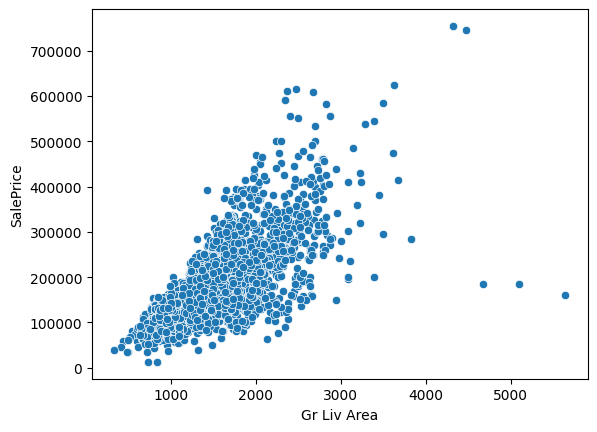

In [41]:
sns.scatterplot(x='Gr Liv Area', y = 'SalePrice', data = df)

In this case we should worry about the properties with 'Gr Liv Area' value arround 5000, which break the trend sideways. Those are crearly outliers. The ones arround 4500 and with prices over 700.000, seem to be in the trend, just way too expensive.

Let's look for the outliers (chances are, they are the same as the outliers for the 'Overall Qual' feature)

In [42]:
df[(df['Overall Qual']>8) & (df['SalePrice']<200000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1182,533350090,60,RL,NaN,24572,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Family,150000
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [43]:
#Let's see if they are those from the previous feature
df[(df['Gr Liv Area']>4000) & (df['SalePrice']<400000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


Indeed they are. For this exercise it is OK, we can do with cleaning the outliers to this two features. But, as homework, let's check the next feature according to the correlation: 'Garage Cars'.

<Axes: xlabel='Garage Cars', ylabel='SalePrice'>

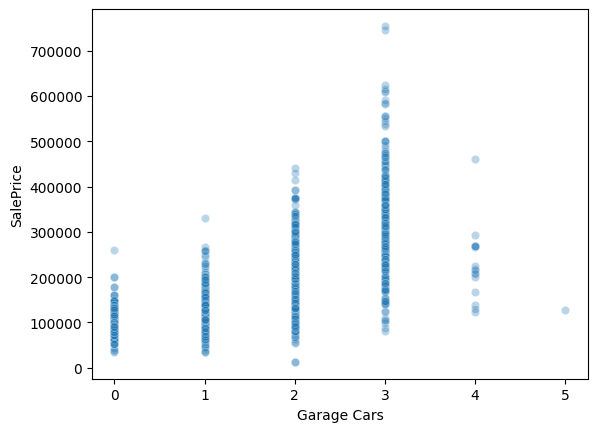

In [48]:
sns.scatterplot(x='Garage Cars', y = 'SalePrice', data = df, alpha=0.3)

Let's check for the outliers in all the 'Garage Cars' categories: 0, 1, 3, 4 and 5 cars.

In [45]:
df[(df['Garage Cars']==0) & (df['SalePrice']>200000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1407,905426030,30,RL,85.0,19550,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,260000
2045,904101070,50,RL,138.0,18030,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,MnPrv,NaN,0,3,2007,WD,Normal,200500


In [46]:
df[(df['Garage Cars']==1) & (df['SalePrice']>300000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2256,916253320,120,RM,NaN,9763,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2007,WD,Normal,330000


In [47]:
df[(df['Garage Cars']==3) & (df['SalePrice']>700000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1760,528320050,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000
1767,528351010,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


In [49]:
df[(df['Garage Cars']==4) & (df['SalePrice']>400000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1059,528118090,60,RL,96.0,12539,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,460000


In [50]:
df[(df['Garage Cars']==5)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
746,903236040,30,RM,50.0,8635,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,126500


The outliers for the 'Garage Cars' do not coincide with the others. It may make sense to remove them or not. We will keep them for now. Next feature is 'Garage Area' which will most probably behave as 'Garage Cars'. Let's try with the next in the list: 'Total Bsmt SF'

<Axes: xlabel='Total Bsmt SF', ylabel='SalePrice'>

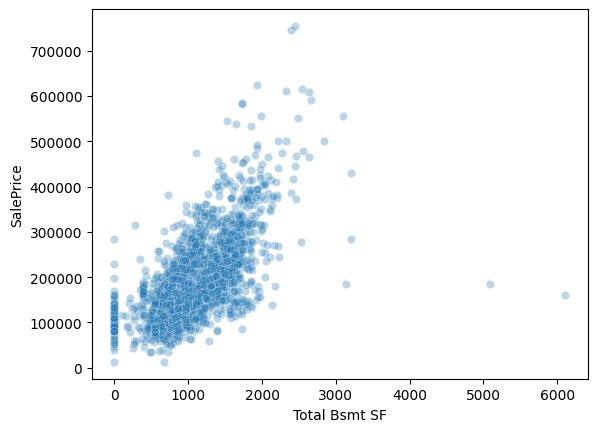

In [51]:
sns.scatterplot(x='Total Bsmt SF', y = 'SalePrice', data = df, alpha=0.3)

Once again we have a couple of properties that break the trend sideways. Let's look at them more closely.

In [52]:
df[(df['Total Bsmt SF']>4000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850


They are indeed two of the usual ones.

We have two observations that are outliers in three of the most representative features and another one that is outlier in the two most representative features.Let's do as to drop them.

In [53]:
ndx_drop=df[(df['Gr Liv Area']>4000) & (df['SalePrice']<400000)].index
df = df.drop(ndx_drop,axis=0)

In [54]:
df[(df['Overall Qual']>8) & (df['SalePrice']<200000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1182,533350090,60,RL,NaN,24572,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Family,150000


They are gone. Let's check for the 'Gr Liv Area' condition

In [55]:
df[(df['Gr Liv Area']>4000) & (df['SalePrice']<400000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


They are gone. Let's look at the scatter plot we had for those features.

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

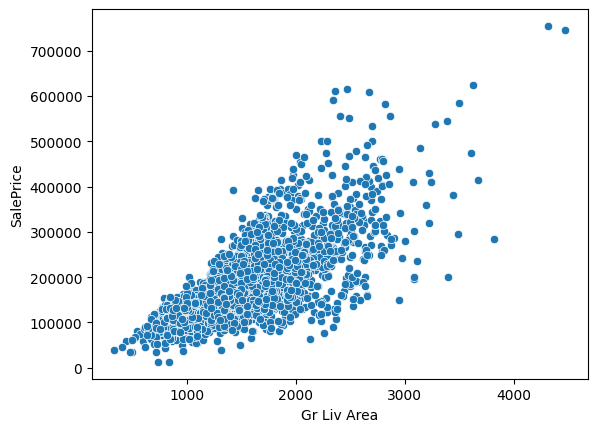

In [56]:
sns.scatterplot(x='Gr Liv Area', y = 'SalePrice', data = df)

The outliers are gone. It is going to be easier to fit a model to this dataset.

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

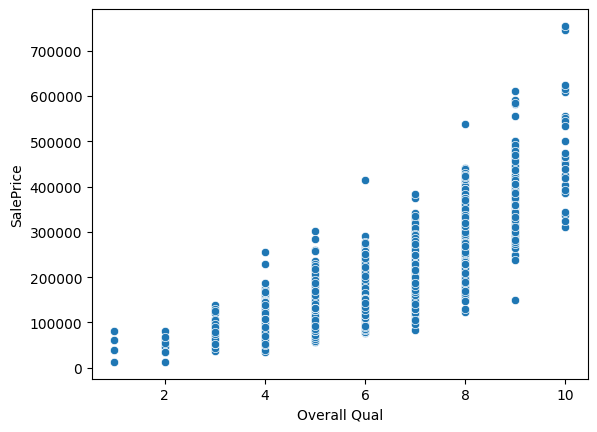

In [57]:
sns.scatterplot(x='Overall Qual', y='SalePrice', data = df)

<Axes: xlabel='Total Bsmt SF', ylabel='SalePrice'>

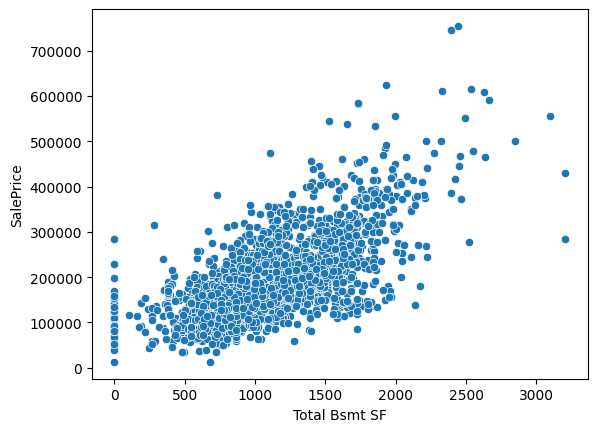

In [58]:
sns.scatterplot(x='Total Bsmt SF', y = 'SalePrice', data = df)

Now the next step would be to save the dataset as we have it now: without the outliers. That would be:
> `df.to_csv('path/to/your/file')`

Fortunatelly, the file has already saved for us by the instructor: ../../DATA/Ames_Outliers_removed.csv